In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
sys.path.append(str(Path().resolve().parent))
import multimin as mm
import time
from utils.Utils import (
    CanonicalUnits, 
    GravitationalParameters,
    surface_integral_P_X_CMND
    )

In [2]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

c:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\density_space_mapping\multimin.py:255: UserWarning: The figure layout has changed to tight
  self.fig.tight_layout()


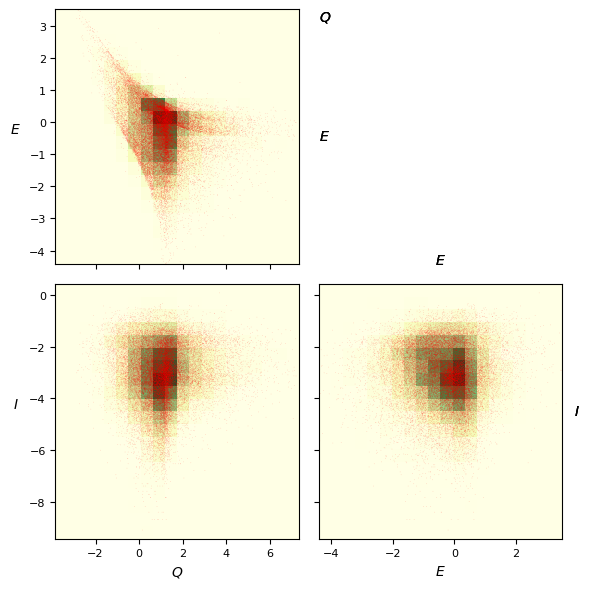

In [3]:
F = mm.FitCMND(f"../multimin/products/fit-NEAs-qei-Ng10-Nv3-rad.pkl")

props=["Q","E","I"]
hargs=dict(bins=20,cmap='YlGn')
sargs=dict(s=0.2,edgecolor='None',color='r', alpha=0.3)
G=F.plotFit(props=props,hargs=hargs,sargs=sargs,figsize=3)

In [5]:
#max elements
max_elements = (1.3, 1.0, np.pi)

# Define center and widths of the phase-space hypercube
c_x = 0.9
c_y = 0.9
c_z = 0
v_x = 0
v_y = (mu/1)**0.5
v_z = 0

dxy = 0.1
dz = 0.5
dvxyz = 5000 * (1/AU_m) * year 

center = (c_x, c_y, c_z, v_x, v_y, v_z)
widths = (dxy, dxy, dz, dvxyz, dvxyz, dvxyz)

start_time = time.time()
#Theoretical: compute expected number of objects in the volume by integrating the distribution
N_theoretical = surface_integral_P_X_CMND(center, widths, max_elements=max_elements, n_points=8, mu=mu, F=F)
print(f"Theoretical (integral) number of objects in volume: {N_theoretical}")
print("--- %s seconds ---" % (time.time() - start_time))

Theoretical (integral) number of objects in volume: 1.0599344603424705e-06
--- 487.8625557422638 seconds ---


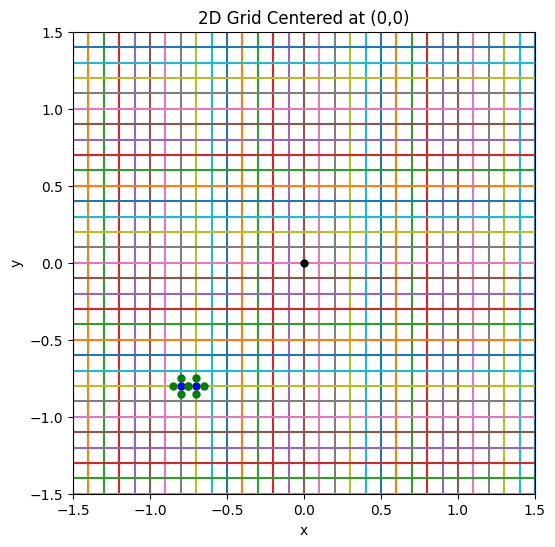

In [6]:
# grid parameters
xmin, xmax = -1.5, 1.5
ymin, ymax = -1.5, 1.5
dx, dy = 0.1, 0.1

# generate grid lines
x_lines = np.arange(xmin, xmax + dx, dx)
y_lines = np.arange(ymin, ymax + dy, dy)

plt.figure(figsize=(6, 6))

# draw vertical lines
for x in x_lines:
    plt.plot([x, x], [ymin, ymax])

# draw horizontal lines
for y in y_lines:
    plt.plot([xmin, xmax], [y, y])

originals = [x_lines[7], y_lines[7]]
originals2 = [x_lines[8], y_lines[7]]
box = [(originals[0] - 0.1/2, originals[0] + 0.1/2), (originals[1] - 0.1/2, originals[1] + 0.1/2)]
box2 = [(originals2[0] - 0.1/2, originals2[0] + 0.1/2), (originals2[1] - 0.1/2, originals2[1] + 0.1/2)]
plt.plot(0, 0, '.', color='black', markersize=10)
plt.plot(originals[0], originals[1], '.', color='blue', markersize=10)
plt.plot(originals2[0], originals2[1], '.', color='blue', markersize=10)
plt.plot(box[0][0], y_lines[7], '.', color='green', markersize=10)
plt.plot(box[0][1], y_lines[7], '.', color='green', markersize=10)
plt.plot(box2[0][0], y_lines[7], '.', color='green', markersize=10)
plt.plot(box2[0][1], y_lines[7], '.', color='green', markersize=10)
plt.plot(x_lines[7], box[1][0], '.', color='green', markersize=10)
plt.plot(x_lines[7], box[1][1], '.', color='green', markersize=10)
plt.plot(x_lines[8], box2[1][0], '.', color='green', markersize=10)
plt.plot(x_lines[8], box2[1][1], '.', color='green', markersize=10)
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Grid Centered at (0,0)")
plt.grid(False)

plt.show()

In [8]:
xmin, xmax = 0.9, 1.2
ymin, ymax = 0.9, 1.2
dx_grid = 0.1
dy_grid = 0.1

x_vals = np.arange(xmin, xmax + dx_grid, dx_grid)
y_vals = np.arange(ymin, ymax + dy_grid, dy_grid)

NX = len(x_vals)
NY = len(y_vals)

# Storage array for results
integral_grid = np.zeros((NX, NY))

fixed_z  = 0.0
fixed_vx = 0.0
fixed_vy = (mu/1)**0.5
fixed_vz = 0.0


dx = 0.1     # width in x
dy = 0.1     # width in y
dz = 0.5
dvx = 5000 * (1/AU_m) * year
dvy = 5000 * (1/AU_m) * year
dvz = 5000 * (1/AU_m) * year

widths = (dx, dy, dz, dvx, dvy, dvz)

max_elements = (1.3, 1.0, np.pi)  # <-- fill with your values

for ix, xv in enumerate(x_vals):
    for iy, yv in enumerate(y_vals):
        vy = (mu/np.abs(xv))**0.5
        center = (xv, yv, fixed_z, fixed_vx, vy, fixed_vz)
        print("evaluating at", center)
        print("widths", widths)

        try:
            val = surface_integral_P_X_CMND(
                center=center,
                widths=widths,
                max_elements=max_elements,
                n_points=8,    
                mu=mu,
                F=F           
            )
        except Exception as err:
            print("Runtime error at center =", center)
            print("   → Setting integral to NaN.")
            #print("   Error message:", err)
            val = np.nan

        integral_grid[ix, iy] = val

np.savetxt("P_X_grid_1.dat", integral_grid)
# Now integral_grid[i,j] holds the integral at (x_vals[i], y_vals[j])
print("Grid computed, shape =", integral_grid.shape)


evaluating at (0.9, 0.9, 0.0, 0.0, 6.623941565868487, 0.0)
widths (0.1, 0.1, 0.5, 1.0547326203208556, 1.0547326203208556, 1.0547326203208556)
evaluating at (0.9, 1.0, 0.0, 0.0, 6.623941565868487, 0.0)
widths (0.1, 0.1, 0.5, 1.0547326203208556, 1.0547326203208556, 1.0547326203208556)
evaluating at (0.9, 1.1, 0.0, 0.0, 6.623941565868487, 0.0)
widths (0.1, 0.1, 0.5, 1.0547326203208556, 1.0547326203208556, 1.0547326203208556)
evaluating at (0.9, 1.2, 0.0, 0.0, 6.623941565868487, 0.0)
widths (0.1, 0.1, 0.5, 1.0547326203208556, 1.0547326203208556, 1.0547326203208556)


C:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\utils\Utils.py:150: RuntimeWarning: invalid value encountered in scalar power
  return (1-e**2)**0.5
C:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\utils\Utils.py:154: RuntimeWarning: invalid value encountered in scalar power
  return (mu*a)**0.5
C:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\utils\Utils.py:733: RuntimeWarning: invalid value encountered in scalar power
  n = (mu/a**3)**0.5
C:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\utils\Utils.py:734: RuntimeWarning: invalid value encountered in scalar power
  factor = -(mu*a**3)**0.5/r**3


Runtime error at center = (0.9, 1.2, 0.0, 0.0, 6.623941565868487, 0.0)
   → Setting integral to NaN.
evaluating at (1.0, 0.9, 0.0, 0.0, 6.2840227308020005, 0.0)
widths (0.1, 0.1, 0.5, 1.0547326203208556, 1.0547326203208556, 1.0547326203208556)
evaluating at (1.0, 1.0, 0.0, 0.0, 6.2840227308020005, 0.0)
widths (0.1, 0.1, 0.5, 1.0547326203208556, 1.0547326203208556, 1.0547326203208556)
evaluating at (1.0, 1.1, 0.0, 0.0, 6.2840227308020005, 0.0)
widths (0.1, 0.1, 0.5, 1.0547326203208556, 1.0547326203208556, 1.0547326203208556)
evaluating at (1.0, 1.2, 0.0, 0.0, 6.2840227308020005, 0.0)
widths (0.1, 0.1, 0.5, 1.0547326203208556, 1.0547326203208556, 1.0547326203208556)
evaluating at (1.1, 0.9, 0.0, 0.0, 5.9915805837886325, 0.0)
widths (0.1, 0.1, 0.5, 1.0547326203208556, 1.0547326203208556, 1.0547326203208556)
evaluating at (1.1, 1.0, 0.0, 0.0, 5.9915805837886325, 0.0)
widths (0.1, 0.1, 0.5, 1.0547326203208556, 1.0547326203208556, 1.0547326203208556)
evaluating at (1.1, 1.1, 0.0, 0.0, 5.9915

KeyboardInterrupt: 

### Grid 1: from Mercury to Mars 

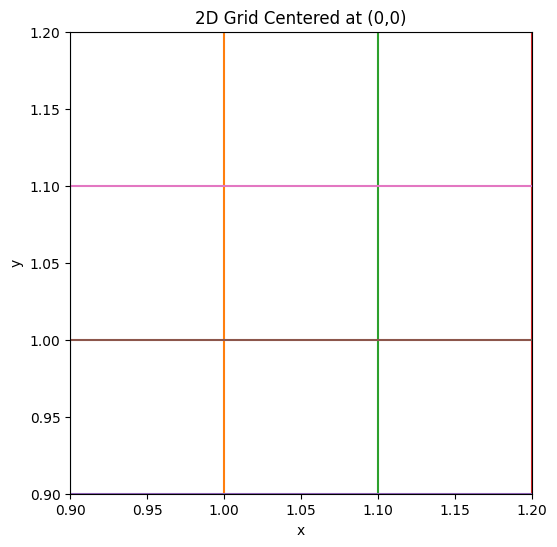

In [7]:
# grid parameters
xmin, xmax = 0.9, 1.2
ymin, ymax = 0.9, 1.2
dx, dy = 0.1, 0.1

# generate grid lines
x_lines = np.arange(xmin, xmax + dx, dx)
y_lines = np.arange(ymin, ymax + dy, dy)

plt.figure(figsize=(6, 6))

# draw vertical lines
for x in x_lines:
    plt.plot([x, x], [ymin, ymax])

# draw horizontal lines
for y in y_lines:
    plt.plot([xmin, xmax], [y, y])

plt.plot(0, 0, '.', color='black', markersize=10)
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Grid Centered at (0,0)")
plt.grid(False)

plt.show()